# Matsuno-Gill problem figures from Nicolas & Vallis (2026): Mechanisms of Superrotation in Slowly-Rotating and Tidally-Locked Planets

Use this notebook to reproduce figures 2 and 3 from the paper.

In [1]:
import numpy as np
import xarray as xr

import matplotlib
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
from plottingTools import stag_latitude,plot_map

from emfcTools import calc_emfc_bvp 

%load_ext autoreload
%autoreload 2

# Numerical solutions

Drag-free solutions of the two-level Matsuno-Gill problem are obtained in Appendix A of the paper. The code below computes the EMFC as a function of the thermal Rossby number and the radiative timescale in this drag-free case.

In [2]:
def EMFC_analytical_2level(Ro_T,tau_rad_nondim,stratification = 0.05):
    """Calculate upper-level EMFC for the drag-free two-level model using the analytical formula derived in Appendix A.

    Parameters
    ----------
    Ro_T: Thermal Rossby number
    tau_rad_nondim: Nondimensional radiative timescale
    stratification: Stratification parameter, which controls the vertical structure of the forcing (default: 0.05)

    Returns
    -------
    EMFC: The upper-level EMFC as a function of latitude.
    """
    theta = np.linspace(0,np.pi,256)
    lat = np.pi/2-theta 
    y = np.sin(lat)
    y = xr.DataArray(y, coords={'latitude':lat*180./np.pi,'y':('latitude',y),'theta':('latitude',theta)}, dims=['latitude'])

    kappa_ = 2/7
    P1 = 0.25**kappa_
    P2 = 0.75**kappa_
    
    sumthetaEs = ((1-stratification*np.log(P1)) + (1-stratification*np.log(P2))) / 2
    
    alpha = (P2-P1)/2
    k = 1

    Kappa = k * alpha * stratification * Ro_T * tau_rad_nondim / 2

    const = sumthetaEs ** 2 * k * alpha**2 * Kappa * Ro_T / 4
    Y = y**2
    return - const  * ( Y * np.sqrt(1-Y) * (Y**3 - 5*Y**2 - 7*Kappa**2*Y + 3*Kappa**2) / (y**4 + Kappa**2)**3 ) 

In [3]:
# Calculate analytical EMFC for the drag-free two-level model
bvp_20_nofriction = EMFC_analytical_2level(1.,20).to_dataset(name='emfc1')
bvp_200_nofriction = EMFC_analytical_2level(1.,200).to_dataset(name='emfc1')

Solutions with drag are not easy to obtain analytically, and we solve for them using Dedalus instead.
The script `two_level_BVP.py` solves the two-level Matsuno-Gill problem in the general case, i.e., including drag.

Use `mpiexec -n 4 python two_level_BVP.py --Ro 1 --Trad 20` and `mpiexec -n 4 python two_level_BVP.py --Ro 1 --Trad 200` to produce the two solutions needed for this notebook.

You can then open them using:

In [4]:
bvp_20 = xr.open_dataset("data/bvp_2levelnondim_T128_halfcoslon_1p00_0p02_20_0p05.nc")
bvp_200 = xr.open_dataset("data/bvp_2levelnondim_T128_halfcoslon_1p00_0p02_200_0p05.nc")

[iacmac-ds4973:39556] shmem: mmap: an error occurred while determining whether or not /var/folders/g5/y1nh4h6x3j3c3lh5frsdkvtc0000gq/T//ompi.iacmac-ds4973.503/jf.0/2053111808/sm_segment.iacmac-ds4973.503.7a600000.0 could be created.


In [5]:
# Calculate EMFC for the BVP solutions
for bvp in bvp_20,bvp_200:
    calc_emfc_bvp(bvp,1.)

In [6]:
bvps = {(20 ,'friction'):bvp_20,
        (200,'friction'):bvp_200,
        (20 ,'nofriction'):bvp_20_nofriction,
        (200,'nofriction'):bvp_200_nofriction,
       }

# Figure 2

Text(0.5, 1.0, 'Lower layer')

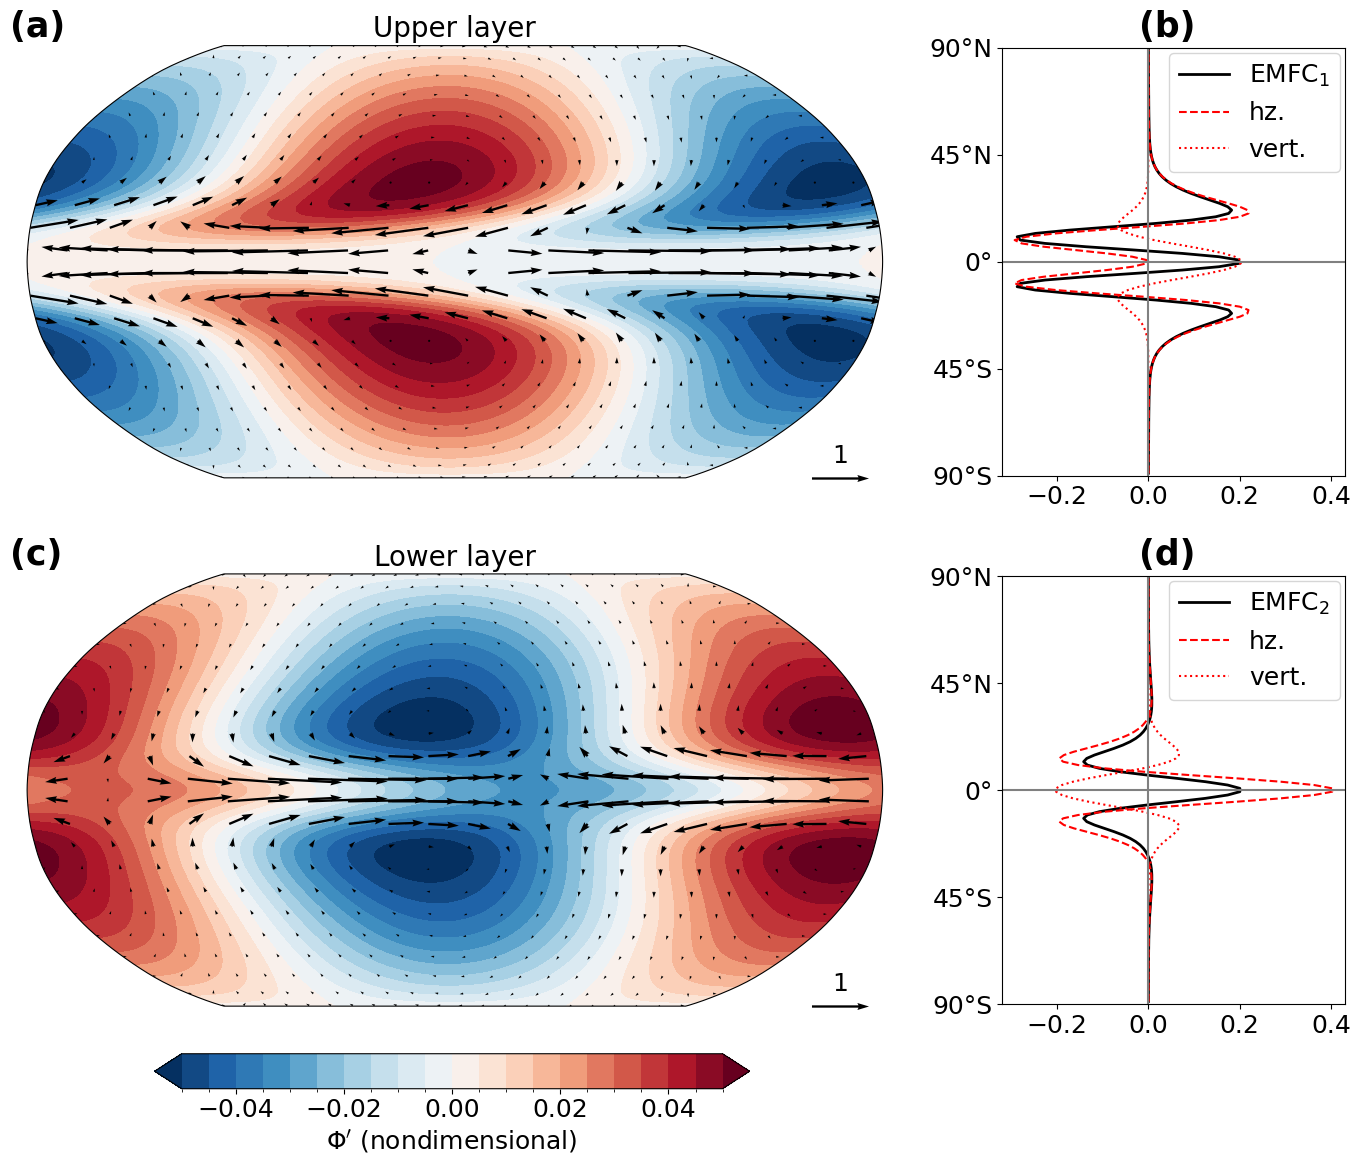

In [7]:
ftz=18
matplotlib.rcParams.update({'font.size':ftz})

fig = plt.figure(figsize=(17,14))
eps = 0.025
gs = gridspec.GridSpec(nrows=7, ncols=2, width_ratios=[1, 0.4], height_ratios = [eps,1,eps,eps,1,eps,0.05], figure=fig)
ax1 = fig.add_subplot(gs[0:3, 0], projection=ccrs.Robinson())
ax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[3:6, 0], projection=ccrs.Robinson())
ax4 = fig.add_subplot(gs[4, 1])
axcbar = fig.add_subplot([0.2,0.11,0.35,0.025]) 
axs = [[ax1,ax2],[ax3,ax4]]

bvp = bvp_20

MM = 0.05 # Maximum contour value for the geopotential
ticks = np.linspace(-0.04,0.04,5) # colorbar ticks

for i in range(2): # Loop over layers
    layer = i+1

    # Map
    u_new = stag_latitude(bvp['u%i'%layer])
    c = plot_map(axs[i][0],bvp['Phi%i'%layer],u_new.transpose('component','longitude','latitude'),
                                   vmin=None,vmax=None,levels=np.linspace(-MM,MM,21),extend='both',cmap=plt.cm.RdBu_r,
                                   wind_disc=6,quiver_kwargs=dict(scale=15),include_qk=True,qk_scale=1, qkx=0.95, qky=0.,
                                   add_colorbar=False,
                                   startlat=0)
    
    # EMFC plot
    clr = 'r'    
    bvp['emfc%i'%layer].plot(ax = axs[i][1], y='latitude',color='k',linewidth=2,label='EMFC$_%i$'%layer)
    vflux = (-1)**layer * bvp['omegaubar']
    (bvp['emfc%i'%layer] - vflux).plot(ax = axs[i][1], y='latitude',color=clr,linestyle='--',linewidth=1.5,label='hz.')
    vflux.plot(ax = axs[i][1], y='latitude',color=clr,linestyle=':',linewidth=1.5,label='vert.')

    axs[i][1].axhline(0.,color='gray')
    axs[i][1].axvline(0.,color='gray')
    axs[i][1].set_xlim(-0.32,0.43)
    axs[i][1].set_ylim(-90,90)
    axs[i][1].set_yticks(range(-90,91,45))
    axs[i][1].set_yticklabels(['90°S','45°S','0°','45°N','90°N'])
    axs[i][1].set_ylabel('')
    axs[i][1].set_xlabel('')
    axs[i][1].legend(borderaxespad=0.2)

    axs[i][0].text(-0.02,1.02,["(a)","(c)"][i],fontweight='bold',fontsize=25,transform = axs[i][0].transAxes)
    axs[i][0].text(1.3,1.02,["(b)","(d)"][i],fontweight='bold',fontsize=25,transform = axs[i][0].transAxes)

# Colorbar
plt.colorbar(c, cax=axcbar, orientation = 'horizontal', ticks=ticks,label=r"$\Phi'$ (nondimensional)")

ax1.set_title("Upper layer", fontsize = ftz+2)
ax3.set_title("Lower layer", fontsize = ftz+2)

# fig.savefig('figs/Gillpattern.pdf',format='pdf',bbox_inches='tight')

Text(0.0, 1.02, '(b)')

2026-03-13 15:52:39,395 matplotlib.mathtext 0/1 INFO :: Substituting symbol S from STIXNonUnicode
2026-03-13 15:52:39,407 matplotlib.mathtext 0/1 INFO :: Substituting symbol S from STIXNonUnicode
2026-03-13 15:52:39,411 matplotlib.mathtext 0/1 INFO :: Substituting symbol S from STIXNonUnicode
2026-03-13 15:52:39,414 matplotlib.mathtext 0/1 INFO :: Substituting symbol S from STIXNonUnicode
2026-03-13 15:52:39,416 matplotlib.mathtext 0/1 INFO :: Substituting symbol S from STIXNonUnicode
2026-03-13 15:52:39,423 matplotlib.mathtext 0/1 INFO :: Substituting symbol S from STIXNonUnicode
2026-03-13 15:52:39,486 matplotlib.mathtext 0/1 INFO :: Substituting symbol S from STIXNonUnicode
2026-03-13 15:52:39,496 matplotlib.mathtext 0/1 INFO :: Substituting symbol S from STIXNonUnicode
2026-03-13 15:52:39,500 matplotlib.mathtext 0/1 INFO :: Substituting symbol S from STIXNonUnicode
2026-03-13 15:52:39,504 matplotlib.mathtext 0/1 INFO :: Substituting symbol S from STIXNonUnicode
2026-03-13 15:52:39,

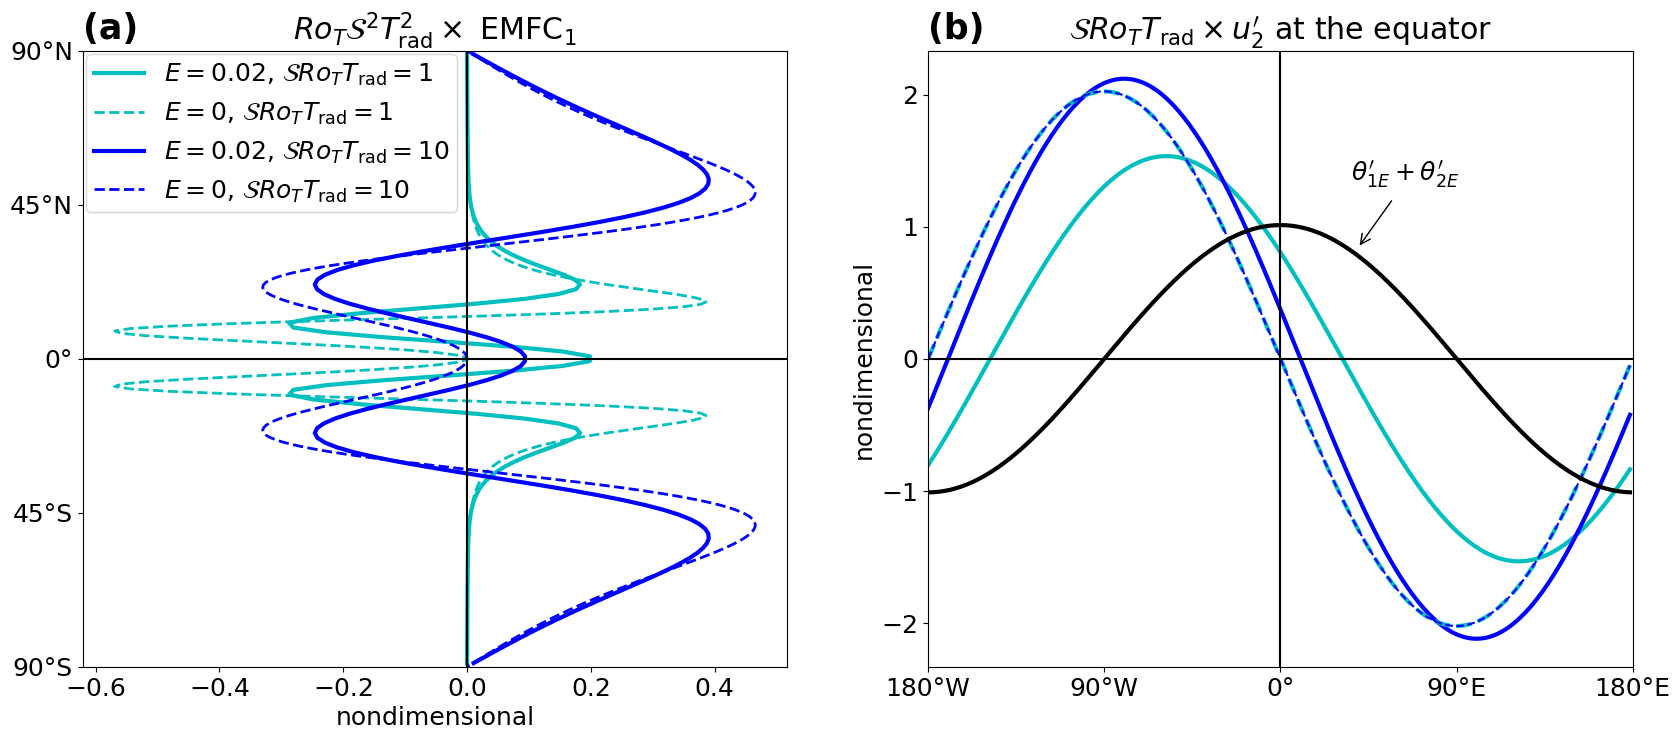

In [8]:
matplotlib.rcParams.update({'font.size':18})
fig,axs = plt.subplots(1,2,figsize = (20,8),width_ratios = [1,1])

colors=['c','b']

########## EMFC plot ########
ax = axs[0]
for i,tau in enumerate((20,200)):
    bvp = bvps[(tau,'friction')]
    (((0.05*tau)**2)*bvp.emfc1).plot(ax=ax, y='latitude', color=colors[i], linestyle='-' , linewidth=3, label=r"$E=0.02$, $\mathcal{S}Ro_T T_\mathrm{rad}=$%i"%(tau*0.05))
    bvp = bvps[(tau,'nofriction')]
    (((0.05*tau)**2)*bvp.emfc1).plot(ax=ax, y='latitude', color=colors[i], linestyle='--', linewidth=2, label=r"$E=0$, $\mathcal{S}Ro_T T_\mathrm{rad}=$%i"%(tau*0.05))

ax.set_xlabel(r"nondimensional")
ax.legend(loc=2, borderaxespad=0.15, borderpad=0.3)
ax.axhline(0.,color='k')
ax.axvline(0.,color='k')
ax.set_ylim(-90,90)
ax.set_yticks(range(-90,91,45))
ax.set_yticklabels(['90°S','45°S','0°','45°N','90°N'])
ax.set_ylabel('')
ax.set_title(r"$Ro_T \mathcal{S}^2 T_\mathrm{rad}^2 \times$ EMFC$_1$")

########## u_2 plot ########
ax = axs[1]

colors=['c','b']
for i,tau in enumerate((20,200)):
    bvp = bvps[(tau,'friction')]
    ((0.05*tau)*bvp.u2[0].sel(latitude=slice(-1,1)).mean('latitude')).plot(ax=ax,x='longitude',color=colors[i],linewidth=3,label=r"$E=0.02$, $\mathcal{S}Ro_T T_\mathrm{rad}=$%i"%(tau*0.05))
for i,tau in enumerate((20,200)):    
    lon = bvp.phi
    gamma = (1 - 0.05*(np.log(0.25**(2/7))+np.log(0.75**(2/7)))/2)
    u2_scaled = 2 * gamma * np.sin(lon)
    u2_scaled.plot(ax=ax,x='longitude',color=colors[i],linewidth=3-1.5*i,linestyle='--',label=r"$E=0$, $\mathcal{S}Ro_T T_\mathrm{rad}=$%i"%(tau*0.05))

bvp = bvps[(20,'friction')]
(bvp.theta1E+bvp.theta2E).sel(latitude=slice(-2,2)).mean('latitude').plot(ax=ax,color='k',linewidth=3,label=r"$\theta_{1E}+\theta_{2E}$")


axs[1].text(0.6,0.79, r"$\theta_{1E}'+\theta_{2E}'$",color='k',fontsize=18,transform = axs[1].transAxes)
x0=0.61; y0 = 0.68
axs[1].annotate("", xy=(x0+0.05,y0 + 0.08), xytext=(x0,y0),arrowprops=dict(arrowstyle="<-"),annotation_clip=False, xycoords='axes fraction')


ax.set_ylabel(r"nondimensional")
ax.axhline(0.,color='k')
ax.axvline(0.,color='k')
ax.set_xlim(-180,180)
ax.set_xticks(range(-180,181,90))
ax.set_xticklabels(['180°W','90°W','0°','90°E','180°E'])
ax.set_xlabel('')
ax.set_yticks(np.arange(-2,2.1,1.))
ax.set_title(r"$\mathcal{S} Ro_T T_\mathrm{rad} \times u_2'$ at the equator");

axs[0].text(0.,1.02,"(a)",fontweight='bold',fontsize=25,transform = axs[0].transAxes)
axs[1].text(0.,1.02,"(b)",fontweight='bold',fontsize=25,transform = axs[1].transAxes)
# fig.savefig('figs/gill_emfc_u2.pdf',format='pdf',bbox_inches='tight')
